# 05. Fourier transforms

## Learning goals

- apply a Fourier transform to a one-dimensional QTT using the quantics Fourier operator
- compare the transformed QTT result against an analytic reference
- inspect bond dimensions before and after the transform
- extend the idea to a two-dimensional partial Fourier transform along one coordinate

## Before you run this notebook

From a terminal in the repository root, run:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook in VS Code or Jupyter and select the Julia kernel that matches the version you used for setup. This notebook was last tested with Julia 1.12.

In [100]:
using Tensor4all
using CairoMakie
using FFTW

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const QT = Tensor4all.QuanticsTransform
const TN = Tensor4all.TensorNetworks
const STT = Tensor4all.SimpleTT

Tensor4all.SimpleTT

## Concept

We start from sampled values $f_j$ on a finite grid with $N = 2^R$ points. The discrete Fourier transform of these values is

$$
\widehat f_m = \frac{1}{\sqrt{N}} \sum_{j=0}^{N-1} f_j\, \exp\!\left(-2\pi i \frac{jm}{N}\right),
\qquad m = 0, \dots, N-1.
$$

Here $j$ is the input sample index and $m$ is the raw DFT coefficient index. The physical input coordinate is

$$
x_j = x_{\mathrm{lower}} + j \Delta x,
$$

while the physical frequency coordinate is

$$
k = \frac{s}{N \Delta x}.
$$

Here $s$ is the centered frequency bin. For even $N$, it runs from

$$
s = -\frac{N}{2}, -\frac{N}{2}+1, \dots, -1, 0, 1, \dots, \frac{N}{2}-1.
$$

So $s$ describes the frequencies in the centered physical order that we want for plotting and interpretation. The raw storage index $m$ describes the same coefficients in the order used by the DFT tensor, namely $m = 0, 1, \dots, N-1$. They are related by wrapping modulo $N$:

$$
m = \operatorname{mod}(s, N).
$$

For example, the centered bin $s=-1$ is stored at the raw index $m=N-1$. This is why the notebook later converts centered bins into raw coefficient indices before reading values from the transformed QTT.

In `Tensor4all.jl`, the Fourier transform is provided as an MPO, that is, a tensor-train representation of this discrete linear operator. Applying the MPO to a QTT state gives the normalized discrete Fourier coefficients in raw DFT order. We then reinterpret these coefficients on a physical frequency axis.

To compare the result with the continuous Fourier transform

$$
\widehat f(k) = \int f(x) e^{-2\pi i kx} \, dx,
$$

we use the standard rescaling

$$
\widehat f(k) \approx \Delta x \sqrt{N} \, e^{-2\pi i k x_{\mathrm{lower}}} \, \widehat f_m^{\mathrm{DFT}}.
$$

Each factor has a clear role: $\sqrt{N}$ undoes the built-in DFT normalization, $\Delta x$ turns the discrete sum into a Riemann approximation, and the phase factor corrects for the fact that the physical grid starts at $x_{\mathrm{lower}}$ rather than at zero.

We first work in one dimension with a Gaussian, where the transformed reference is again a Gaussian. Then we extend the same idea to a two-dimensional function and transform only one coordinate, leaving the other coordinate untouched.


## Part 1: One-dimensional Fourier transform

### Target function

We use a Gaussian as the input function. Its Fourier transform is another Gaussian, which makes the comparison straightforward with a compact analytic reference:

$$f(x) = e^{-x^2 / 2} \quad \longrightarrow \quad \hat{f}(k) = \sqrt{2\pi}\, e^{-2\pi^2 k^2}.$$

In [101]:
R = 7
npoints = 1 << R;

In [102]:
target_function(x) = exp(-0.5 * x^2);

### Building the input QTT

We construct the quantics grid on the interval $[-10, 10]$ and build a QTT approximation of the Gaussian with the same workflow as earlier notebooks.

In [103]:
grid = QG.DiscretizedGrid{1}(R, -10.0, 10.0; includeendpoint=true)
xvals = [QG.grididx_to_origcoord(grid, i) for i in 1:npoints]

qtt, _, _ = QTCI.quanticscrossinterpolate(
    Float64, target_function, grid;
    tolerance=1e-10, maxbonddim=32, maxiter=200,
)

simple_tt = STT.TensorTrain(qtt.tci)
sites = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(simple_tt)]
state = TN.TensorTrain(simple_tt, sites) 

bond_dims_before = TN.linkdims(state)

println("R = $R gives $npoints grid points from -10 to 10.")
println("Input bond dimensions: $bond_dims_before")

R = 7 gives 128 grid points from -10 to 10.
Input bond dimensions: [2, 4, 6, 8, 4, 2]


The quantics Fourier operator is available through `QuanticsTransform.fourier_operator`. It returns a `TensorNetworks.LinearOperator` that we can apply directly to the state.

Before applying it, we bind the operator input and output spaces with `set_iospaces!`. The operator needs to know on which site indices it takes input and on which site indices it returns output. In this example, both are the same `sites`, because the Fourier transform acts on the current QTT state and returns a transformed QTT state on the same index set.

In [104]:
op = QT.fourier_operator(R; forward=true, maxbonddim=32, tolerance=1e-10)

TN.set_iospaces!(op, sites, sites)

result_raw = TN.apply(op, state) 
#truncation can also be done in one step via: TN.apply(op, state; threshold=1e-10, maxdim=32)

bond_dims_after_raw = TN.linkdims(result_raw)

result = TN.truncate(result_raw; threshold=1e-10, maxdim=32)
bond_dims_after = TN.linkdims(result)

operator_bond_dims = TN.linkdims(op.mpo)

println("The Fourier operator was applied to the QTT state.")
println("Bond dimensions of operator: $operator_bond_dims")
println("Bond dimensions immediately after the transform: $bond_dims_after_raw")
println("Bond dimensions after recompression: $bond_dims_after")


The Fourier operator was applied to the QTT state.
Bond dimensions of operator: [2, 4, 8, 8, 4, 2]
Bond dimensions immediately after the transform: [4, 15, 16, 8, 4, 2]
Bond dimensions after recompression: [2, 4, 6, 4, 2, 2]


The bond dimensions grow when we apply the Fourier operator. This is expected: the transform mixes information across sites, and the intermediate QTT needs more internal rank to represent the result.

We then recompress the transformed QTT with `TensorNetworks.truncate`. This keeps the transformed state accurate while removing small singular directions that are not needed at the chosen tolerance.

### Evaluating on the frequency grid

The transformed TensorTrain lives on the same quantics site structure as the input, but the physical meaning of the coordinates has changed: they now index frequency bins. We evaluate the transformed QTT at each frequency grid point and apply a scaling factor to match the continuous Fourier convention.

The scaling factor is $\Delta x \cdot \sqrt{N} \cdot e^{-2\pi i k x_{\mathrm{lower}}}$, where $\Delta x$ is the input grid spacing and $x_{\mathrm{lower}} = -10$.


In [105]:
delta_x = 20.0 / (npoints - 1)
frequency_step = 1.0 / (npoints * delta_x)
k_lower = -(npoints / 2.0) * frequency_step
k_upper = k_lower + (npoints - 1) * frequency_step
kvals = range(k_lower, k_upper, length=npoints)

output_sites = [only(inds) for inds in TN.siteinds(result)]

function quantics_digits(i, r)
    d = Base.digits(i - 1; base=2, pad=r)
    return [x == 0 ? 1 : 2 for x in reverse(d)]
end

fourier_qtt = ComplexF64[]
fourier_ref = ComplexF64[]
abs_errors = Float64[]

for (ki, k) in enumerate(kvals)
    centered_bin = ki - 1 - npoints ÷ 2
    coefficient_index = mod(centered_bin, npoints)
    site_vals = quantics_digits(coefficient_index + 1, R)
    reverse!(site_vals)
    raw_val = TN.evaluate(result, output_sites, site_vals)

    scale = delta_x * sqrt(Float64(npoints))
    phase = exp(-2π * im * k * (-10.0))
    qtt_val = raw_val * scale * phase

    exact = sqrt(2π) * exp(-2π^2 * k^2)

    push!(fourier_qtt, qtt_val)
    push!(fourier_ref, exact)
    push!(abs_errors, abs(qtt_val - exact))
end

max_abs_error = maximum(abs_errors)
println("Maximum absolute error vs analytic reference: $(round(max_abs_error, sigdigits=3))")

Maximum absolute error vs analytic reference: 1.27e-12


The error is near machine precision. This confirms that the quantics Fourier operator produces an accurate frequency-space representation.

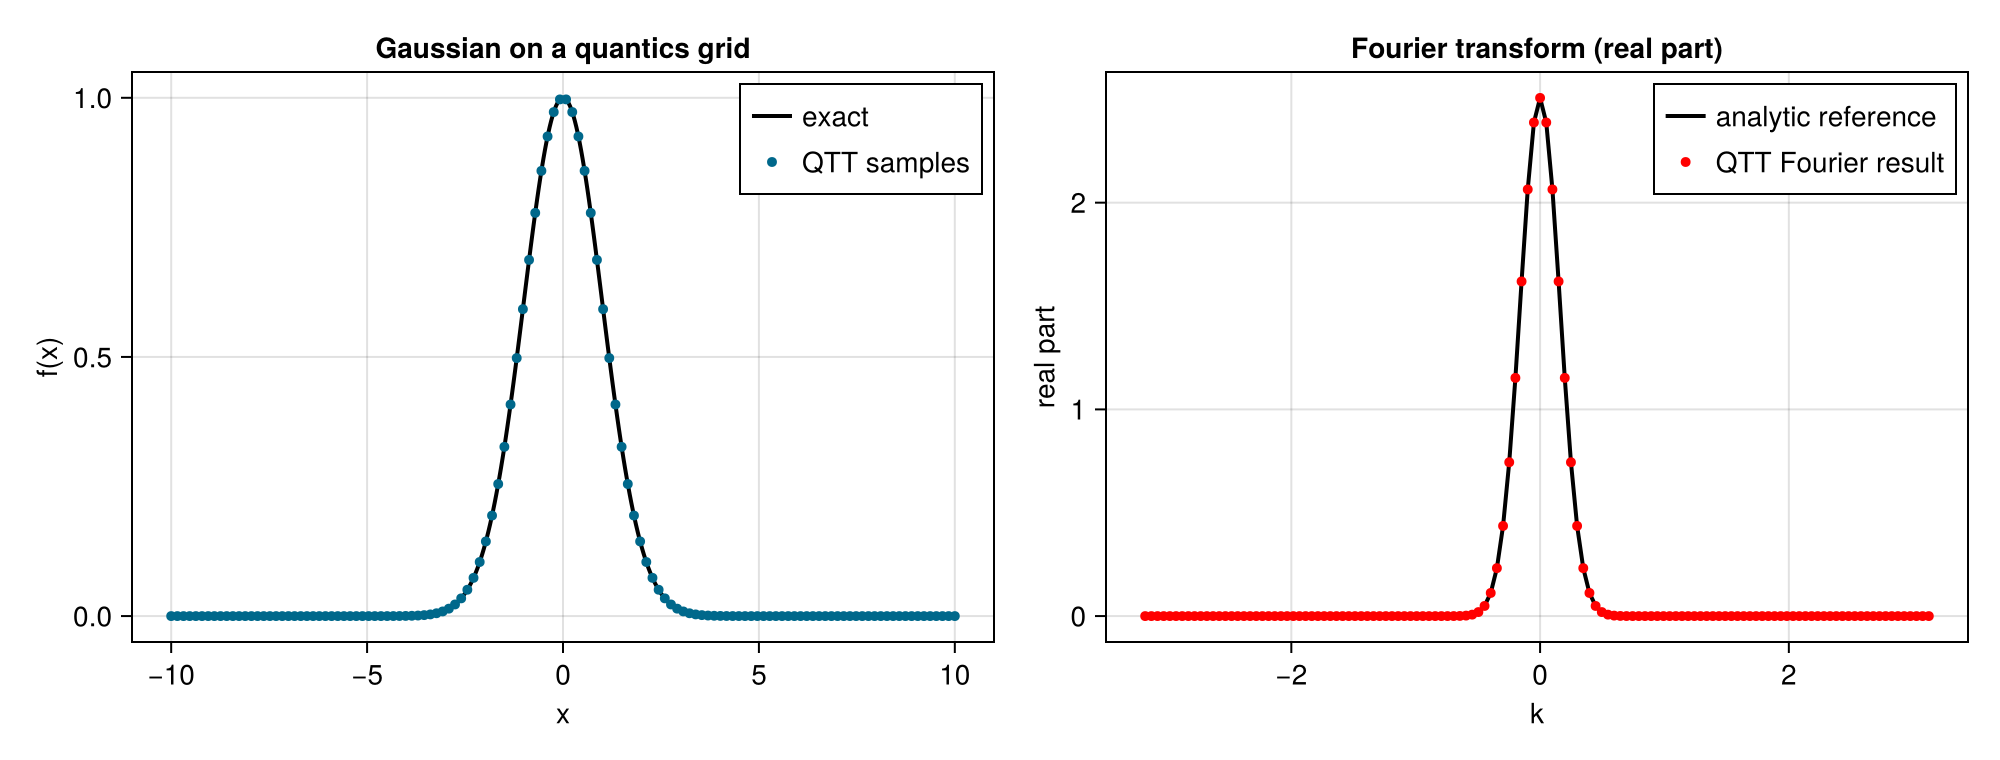

In [117]:
fig1 = Figure(size=(1000, 380))

ax_orig = Axis(
    fig1[1, 1],
    xlabel="x", ylabel="f(x)",
    title="Gaussian on a quantics grid",
)
xs_dense = range(-10, 10, length=500)
lines!(ax_orig, xs_dense, target_function.(xs_dense); color=:black, linewidth=2, label="exact")
scatter!(ax_orig, xvals, [real(qtt(i)) for i in 1:npoints]; color=:deepskyblue4, markersize=7, label="QTT samples")
axislegend(ax_orig; position=:rt)

ax_freq = Axis(
    fig1[1, 2],
    xlabel="k", ylabel="real part",
    title="Fourier transform (real part)",
)
lines!(ax_freq, kvals, real.(fourier_ref); color=:black, linewidth=2, label="analytic reference")
scatter!(ax_freq, kvals, real.(fourier_qtt); color=:red, markersize=7, label="QTT Fourier result")
axislegend(ax_freq; position=:rt)

fig1

The left panel shows the original Gaussian on the quantics grid. The right panel shows the real part of the Fourier-transformed result: the QTT values (blue markers) lie exactly on the analytic Gaussian-in-frequency curve (black line).

### Bond dimensions before, after, and after recompression

We now compare the bond-dimension profiles directly. The input QTT for a Gaussian has a moderate profile. The raw transformed QTT has larger internal bonds because the Fourier operator introduces additional correlations across the quantics sites. After recompression, some of those bonds can shrink again while keeping the transformed representation accurate.


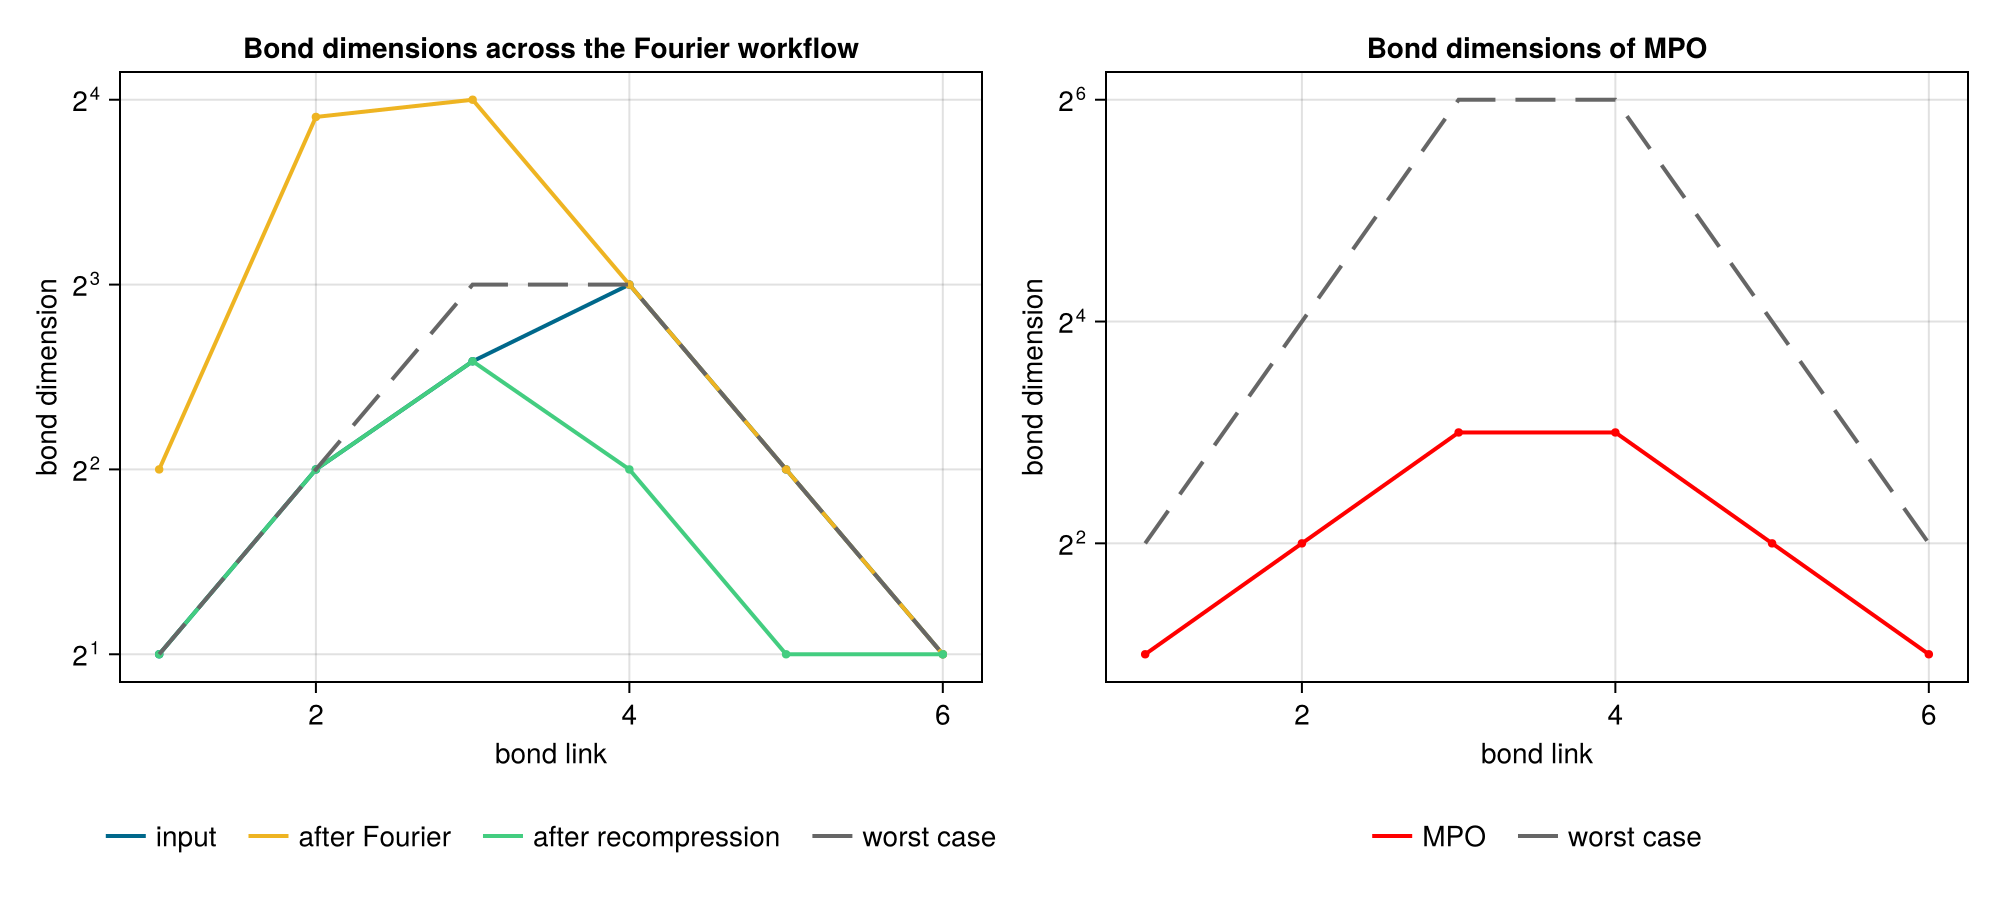

In [107]:
worst_case_bond_dims(num_bonds; base=2) = [base^min(k, num_bonds + 1 - k) for k in 1:num_bonds]

fig_bd1 = Figure(size=(1000, 450))
ax_bd = Axis(
    fig_bd1[1, 1],
    xlabel="bond link", ylabel="bond dimension",
    title="Bond dimensions across the Fourier workflow",
    yscale=log2,
)
num_bonds = maximum((length(bond_dims_before), length(bond_dims_after_raw), length(bond_dims_after)))
worst_case = worst_case_bond_dims(num_bonds)

idx = 1:length(bond_dims_before)
lines!(ax_bd, idx, bond_dims_before; color=:deepskyblue4, linewidth=2, label="input")
scatter!(ax_bd, idx, bond_dims_before; color=:deepskyblue4, markersize=6)

idx2 = 1:length(bond_dims_after_raw)
lines!(ax_bd, idx2, bond_dims_after_raw; color=:goldenrod2, linewidth=2, label="after Fourier")
scatter!(ax_bd, idx2, bond_dims_after_raw; color=:goldenrod2, markersize=6)

idx3 = 1:length(bond_dims_after)
lines!(ax_bd, idx3, bond_dims_after; color=:seagreen3, linewidth=2, label="after recompression")
scatter!(ax_bd, idx3, bond_dims_after; color=:seagreen3, markersize=6)

idx_wc = 1:length(worst_case)
lines!(ax_bd, idx_wc, worst_case; color=:gray40, linewidth=2, linestyle=Linestyle([0, 10, 15]), 
        label="worst case")
Legend(fig_bd1[2, 1], ax_bd, orientation=:horizontal, framevisible=false)

ax_mpo = Axis(
    fig_bd1[1, 2],
    xlabel="bond link", ylabel="bond dimension",
    title="Bond dimensions of MPO",
    yscale=log2,
)

idx4 = 1:length(operator_bond_dims)
lines!(ax_mpo, idx4, operator_bond_dims; color=:red, linewidth=2, label="MPO")
scatter!(ax_mpo, idx4, operator_bond_dims; color=:red, markersize=6)


wc_mpo = worst_case_bond_dims(num_bonds; base =4)
idx_wc = 1:length(wc_mpo)
lines!(ax_mpo, idx_wc, wc_mpo; color=:gray40, linewidth=2, linestyle=Linestyle([0, 10, 15]), 
        label="worst case")

Legend(fig_bd1[2, 2], ax_mpo, orientation=:horizontal, framevisible=false)

fig_bd1


In the left panel, the raw transformed QTT has the largest bond dimensions, especially in the middle of the chain. The dashed gray curve shows a simple worst-case envelope for a state-like QTT. Even after the Fourier transform, the observed bond dimensions stay well below that ceiling.

The recompressed QTT keeps the same transformed content but removes part of the extra internal rank. This is often useful in practice: applying an operator may increase the bond dimensions temporarily, and a subsequent truncation step can bring them back down to a more compact profile.

The right panel shows the bond dimensions of the Fourier MPO itself. Its dashed gray curve uses a steeper worst-case envelope because an MPO carries both input and output legs at each site. The operator bond dimensions determine how much information can flow through the transform and are set by the `maxbonddim` and `tolerance` parameters used when constructing the operator.


## Part 2: Two-dimensional partial Fourier transform

We now consider a two-dimensional function where one coordinate is transformed and the other is left in physical space. This is a partial Fourier transform.

The target function is

$$f(x, t) = e^{-x^2 / 2} \cdot \cos(2\pi \cdot 3 \cdot t),$$

which is a Gaussian in $x$ and a cosine in $t$. The partial Fourier transform along $x$ gives

$$\hat{f}(k, t) = \sqrt{2\pi}\, e^{-2\pi^2 k^2} \cdot \cos(2\pi \cdot 3 \cdot t),$$

which is a Gaussian in $k$ multiplied by the same cosine in $t$.

In [108]:
R2 = 5
npoints2 = 1 << R2

f2(x, t) = exp(-0.5 * x^2) * cos(2π * 3 * t)

f2 (generic function with 1 method)

### Building the 2D QTT

We use an interleaved layout so the quantics bits alternate between $x$ and $t$.

In [109]:
grid2 = QG.DiscretizedGrid(
    (:x, :t), (R2, R2);
    lower_bound=(-10.0, 0.0),
    upper_bound=(10.0, 1.0),
    unfoldingscheme=:interleaved,
    includeendpoint=true,
)

qtt2, _, _ = QTCI.quanticscrossinterpolate(
    Float64, f2, grid2;
    tolerance=1e-10, maxbonddim=64, maxiter=20,
)

simple_tt2 = STT.TensorTrain(qtt2.tci)
sites2 = [Tensor4all.Index(2; tags=["x", "bit=$i"]) for i in 1:length(simple_tt2)]
state2 = TN.TensorTrain(simple_tt2, sites2)

bond_dims_2d_before = TN.linkdims(state2)

println("2D grid: $(npoints2) x $(npoints2) points, interleaved layout.")
println("Input bond dimensions: $bond_dims_2d_before")

2D grid: 32 x 32 points, interleaved layout.
Input bond dimensions: [2, 4, 8, 8, 8, 8, 4, 4, 2]


### Grid evaluation and partial Fourier transform

We evaluate the 2D QTT on the full $(2^{R_2} \times 2^{R_2})$ grid and apply a one-dimensional FFT along the $x$ direction on each fixed-$t$ slice. So for every value of $t$, we transform only the $x$-dependence of the function.

As in the one-dimensional example, the raw FFT output must then be reordered into centered frequency bins and rescaled to match the continuous Fourier convention on the physical $k$ axis. We then build a new QTT from these mixed $(k, t)$ values so that we can inspect the bond structure of the partially transformed function.


In [110]:
grid_vals = zeros(Float64, npoints2, npoints2)
for j in 1:npoints2
    for i in 1:npoints2
        grid_vals[i, j] = qtt2([i, j])
    end
end

x_coords = [QG.grididx_to_origcoord(grid2, (i, 1))[1] for i in 1:npoints2]
t_coords = [QG.grididx_to_origcoord(grid2, (1, j))[2] for j in 1:npoints2]

delta_x2 = x_coords[2] - x_coords[1]
freq_step2 = 1.0 / (npoints2 * delta_x2)
kvals2 = [(ki - 1 - npoints2 ÷ 2) * freq_step2 for ki in 1:npoints2]
tvals2 = t_coords

ft_scaled = zeros(ComplexF64, npoints2, npoints2)
for j in 1:npoints2
    raw_fft = fft(grid_vals[:, j]) / sqrt(Float64(npoints2))
    for (ki, k) in enumerate(kvals2)
        centered_bin = ki - 1 - npoints2 ÷ 2
        coefficient_index = mod(centered_bin, npoints2) + 1
        phase = exp(-2π * im * k * (-10.0))
        ft_scaled[ki, j] = raw_fft[coefficient_index] * delta_x2 * sqrt(Float64(npoints2)) * phase
    end
end

println("Evaluated the QTT on the full $(npoints2)x$(npoints2) grid.")
println("Applied the FFT along the x direction, then reordered and rescaled the output onto the physical frequency grid.")


Evaluated the QTT on the full 32x32 grid.
Applied the FFT along the x direction, then reordered and rescaled the output onto the physical frequency grid.


In [111]:
ft_qtt, _, _ = QTCI.quanticscrossinterpolate(ft_scaled; tolerance=1e-8, maxbonddim=64, maxiter=20)

simple_ft = STT.TensorTrain(ft_qtt.tci)
sites_ft = [Tensor4all.Index(2; tags=["k", "bit=$i"]) for i in 1:length(simple_ft)]
state_ft = TN.TensorTrain(simple_ft, sites_ft)

bond_dims_2d_after = TN.linkdims(state_ft)

println("Partial Fourier bond dimensions: $bond_dims_2d_after")

# Quick reconstruction check
ft_reconst = zeros(ComplexF64, npoints2, npoints2)
for j in 1:npoints2
    for i in 1:npoints2
        ft_reconst[i, j] = ft_qtt([i, j])
    end
end
reconstruction_error = maximum(abs.(ft_reconst .- ft_scaled))
println("Reconstruction error of the partial Fourier QTT: $(round(reconstruction_error, sigdigits=3))")


Partial Fourier bond dimensions: [2, 4, 8, 8, 8, 8, 4, 4, 2]
Reconstruction error of the partial Fourier QTT: 1.36e-15


### Visual comparison

We show three panels: the original two-dimensional function, the real part of the partially transformed QTT reconstruction, and the analytic reference on the same $(k, t)$ grid.


In [112]:
reference = zeros(ComplexF64, npoints2, npoints2)
for (tj, t) in enumerate(tvals2)
    for (ki, k) in enumerate(kvals2)
        reference[ki, tj] = sqrt(2π) * exp(-2π^2 * k^2) * cos(2π * 3 * t)
    end
end

max_abs_error_2d = maximum(abs.(ft_reconst .- reference))
println("Maximum absolute error of the partial Fourier transform vs analytic reference: $(round(max_abs_error_2d, sigdigits=3))")


Maximum absolute error of the partial Fourier transform vs analytic reference: 1.78e-5


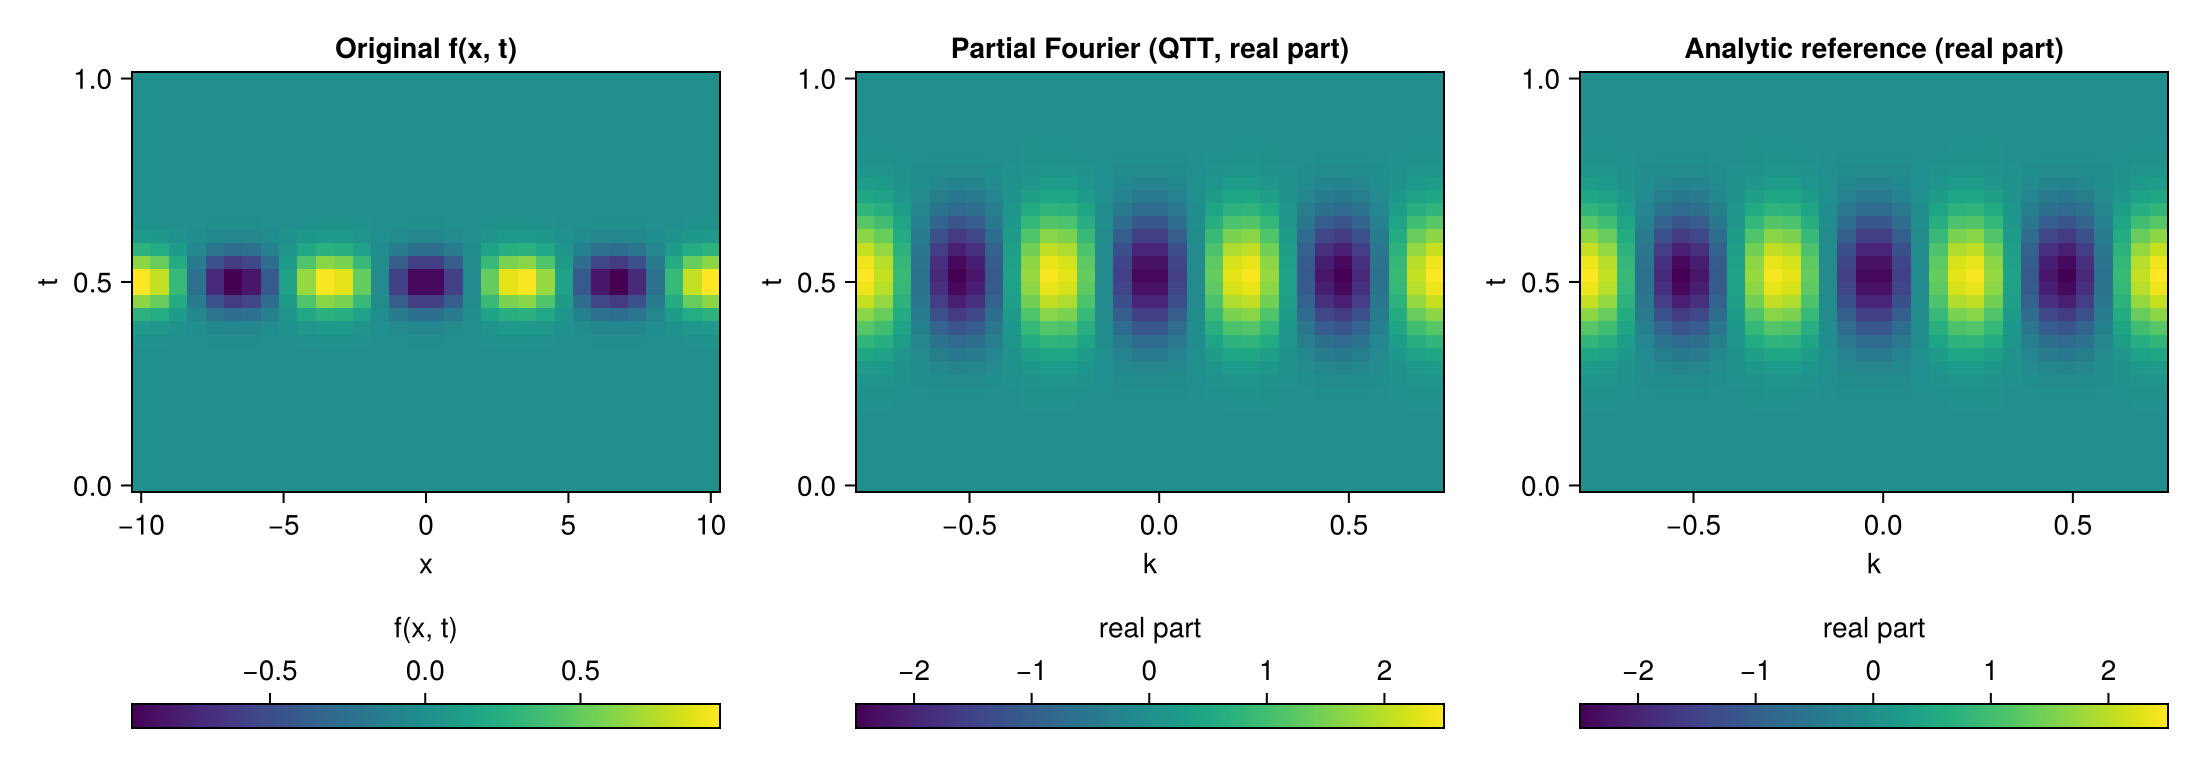

In [113]:
fig2 = Figure(size=(1100, 380))

ax_h1 = Axis(
    fig2[1, 1],
    xlabel="x", ylabel="t",
    title="Original f(x, t)",
)
hm1 = heatmap!(ax_h1, x_coords, t_coords, grid_vals'; colormap=:viridis, interpolate=false)
Colorbar(fig2[2, 1], hm1; vertical=false, label="f(x, t)")

transform_limits = extrema(vcat(vec(real.(ft_reconst)), vec(real.(reference))))

ax_h2 = Axis(
    fig2[1, 2],
    xlabel="k", ylabel="t",
    title="Partial Fourier (QTT, real part)",
)
hm2 = heatmap!(ax_h2, kvals2, tvals2, real.(ft_reconst)'; colormap=:viridis, interpolate=false, colorrange=transform_limits)
Colorbar(fig2[2, 2], hm2; vertical=false, label="real part")

ax_h3 = Axis(
    fig2[1, 3],
    xlabel="k", ylabel="t",
    title="Analytic reference (real part)",
)
hm3 = heatmap!(ax_h3, kvals2, tvals2, real.(reference)'; colormap=:viridis, interpolate=false, colorrange=transform_limits)
Colorbar(fig2[2, 3], hm3; vertical=false, label="real part")

fig2


The original function (left) varies as a Gaussian in $x$ and oscillates in $t$. After the partial Fourier transform (center), the $x$-dependence becomes a Gaussian in $k$, while the $t$-dependence remains the same oscillation. The QTT reconstruction and the analytic reference are shown on the same centered frequency grid and with the same color range, so the visual comparison is meaningful.

The key point is that only the $x$ coordinate was transformed. The $t$ coordinate was left in physical space. This is what a partial transform means: one axis moves to frequency space, while the other stays exactly in the original variable.


### Bond dimensions before and after the partial transform

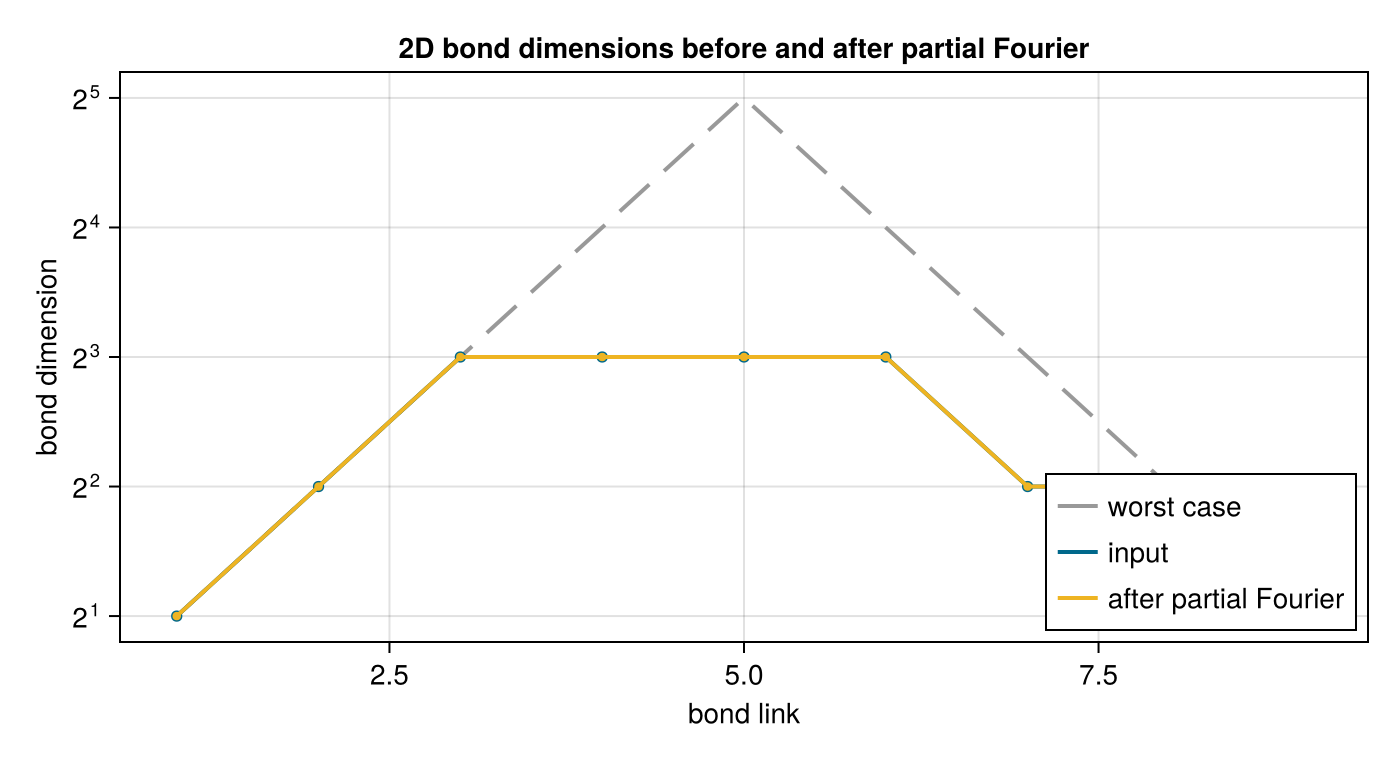

In [118]:
fig_bd2 = Figure(size=(700, 380))
ax_bd2 = Axis(
    fig_bd2[1, 1],
    xlabel="bond link", ylabel="bond dimension",
    title="2D bond dimensions before and after partial Fourier",
    yscale=log2,
)
num_bonds2 = maximum((length(bond_dims_2d_before), length(bond_dims_2d_after)))
worst_case2 = worst_case_bond_dims(num_bonds2)
idx_wc2 = 1:length(worst_case2)
lines!(ax_bd2, idx_wc2, worst_case2; color=:gray60, linewidth=2, linestyle=Linestyle([0, 10, 15]), label="worst case")

idx = 1:length(bond_dims_2d_before)
lines!(ax_bd2, idx, bond_dims_2d_before; color=:deepskyblue4, linewidth=2, label="input")
scatter!(ax_bd2, idx, bond_dims_2d_before; color=:deepskyblue4, markersize=8)

idx2 = 1:length(bond_dims_2d_after)
lines!(ax_bd2, idx2, bond_dims_2d_after; color=:goldenrod2, linewidth=2, label="after partial Fourier")
scatter!(ax_bd2, idx2, bond_dims_2d_after; color=:goldenrod2, markersize=6)
axislegend(ax_bd2; position=:rb)

fig_bd2


In this example the bond dimensions stay the same after the partial Fourier transform. That matches the structure of this particular test function: we transform the Gaussian factor in $x$, while the cosine factor in $t$ stays untouched. So the partial transform changes the meaning of the first coordinate without making the overall representation more complicated in this example.


## What to notice

- The quantics Fourier operator (`QuanticsTransform.fourier_operator`) is built as an MPO and can be applied to any compatible QTT state.
- Bond dimensions can grow under the Fourier transform because the operator introduces additional correlations across quantics sites.
- A transformed QTT can be recompressed with `TensorNetworks.truncate` to reduce bond dimensions again while preserving the result within the chosen tolerance.
- The transformed result can be evaluated on the frequency grid and compared against an analytic reference.
- A partial Fourier transform transforms one coordinate while leaving the other untouched. This can change the bond structure, but in the current separable example the bond dimensions stay unchanged.
- The QTT preserves the Fourier-transformed values accurately enough to match the analytic reference very closely in both examples shown here.


## API recap

- `Tensor4all.QuanticsTransform.fourier_operator` (build the quantics Fourier MPO)
- `Tensor4all.TensorNetworks.set_iospaces!` (bind operator input/output spaces)
- `Tensor4all.TensorNetworks.apply` (apply the Fourier operator to a TensorTrain)
- `Tensor4all.TensorNetworks.truncate` (recompress a TensorTrain after the transform)
- `Tensor4all.TensorNetworks.linkdims` (inspect bond dimensions)
- `Tensor4all.TensorNetworks.evaluate` (evaluate the transformed TensorTrain on the frequency grid)
- `Tensor4all.QuanticsTCI.quanticscrossinterpolate` (build a new QTT from a dense array)
